## Feature Engineering and Encoding

### Import Python Libraries and set properties for the notebook

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import duckdb
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from scipy.stats import chi2_contingency

In [8]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### Import data from the raw file

In [9]:
filepath = '../data/interim/neiss_interim_data.parquet'
#data_interim = pd.read_parquet(filepath)

In [53]:
data_interim = duckdb.read_parquet(filepath).to_df()

In [48]:
type(data_interim)

_duckdb.DuckDBPyRelation

In [59]:
duckdb.sql("SELECT data_year as Year, count(*) as Count FROM data_interim group by data_year order by data_year").to_df()

,Year,Count
0,2005,360372
1,2006,363609
2,2007,369832
3,2008,374260
4,2009,391944
5,2010,405710
6,2011,396502
7,2012,394383
8,2013,376926
9,2014,367492


In [11]:
# Deep copy to preserve original data
data = data_interim.copy()

In [12]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight',
       'True_Age'],
      dtype='str')

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 27 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

### 1. Feature Engineering 

#### 1.1 Add Hospitalization Feature

To develop statistically sound predictive models to reliably identify factors associated with hospitalization of product-related injuries; we need to create a target variable for Hospitalized (Yes/No) for each injury reported based on the disposition code.

In [14]:
# B. Define Target Variable (Hospitalization)
# Disposition Codes:
# 1=Released, 2=Transferred, 4=Hospitalized, 5=Held for Obs, 6=Left, 8=Fatality
# We group 2, 4, 5, and 8 as "Severe/Hospitalized"
disposition_codes = [2, 4, 5, 8]
data['Hospitalized'] = data['Disposition'].apply(lambda x: 1 if x in disposition_codes else 0)

In [15]:
Hospitalized_df = data.Hospitalized.value_counts(normalize=True).reset_index()
Hospitalized_df.columns = ['Hospitalized', 'Percentage']
print(Hospitalized_df)

   Hospitalized  Percentage
0             0        0.91
1             1        0.09


Data is unbalanced and we need to use any of the below techniques to balance the dataset.
1. Use the "class weight" parameter 
2. Use SMOTE (Oversampling) method 
3. Under Sampling - use all of the hospitalized data and take equal number of not_hospitalized data randomly. Could cause uncertain results.

#### 1.2 Add True Alcohol Flag

In [16]:
data.Alcohol.value_counts()

Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64

In [17]:
# Create a list of keywords (standard NEISS abbreviations)
alcohol_keywords = [
    # Medical & Formal
    'ALCOHOL', 'ETOH', 'INTOXICATED', 'INEBRIATED', 'DRUNK', 
    'SOBER', # Often appears as "Not Sober" or "Sobering up"
    'BAC ',  # Blood Alcohol Content (Need the space to avoid 'BACK')
    
    # Beverages
    'BEER', 'WINE', 'LIQUOR', 'VODKA', 'WHISKEY', 'WHISKY', 
    'TEQUILA', 'RUM', 'GIN', 'BRANDY', 'CHAMPAGNE', 'MOONSHINE',
    
    # Actions/Context
    'DRINKING', 'PARTY', 'BAR', 'PUB', 'CLUB', 'TAVERN',
    'HAPPY HOUR', 'KEG'
]

# Create a new column that searches the Narrative for these words
# Returns True if found, False if not
data['Alcohol_byNarrative'] = data['Narrative_1'].str.contains('|'.join(alcohol_keywords), case=False, na=False)
data['Alcohol_byNarrative'] = data['Alcohol_byNarrative'].astype(float)

# Check how many you found
#data['True_Alcohol_Flag'] = data['Alcohol_bool'] | data['Alcohol_Text_Flag']
print(data['Alcohol_byNarrative'].value_counts())
print(data['Alcohol'].value_counts())


Alcohol_byNarrative
0.00    6849504
1.00     466228
Name: count, dtype: int64
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64


In [18]:
target_cols = ['Alcohol', 'Alcohol_byNarrative']
data['True_Alcohol'] = 0
mask_3 = data[target_cols].eq(3.0).any(axis=1)
data.loc[mask_3, 'True_Alcohol'] = 2
mask_1 = data[target_cols].eq(1).any(axis=1)
data.loc[mask_1, 'True_Alcohol'] = 1
print(data['Alcohol_byNarrative'].value_counts())
print(data['Alcohol'].value_counts())
print(data['True_Alcohol'].value_counts())


Alcohol_byNarrative
0.00    6849504
1.00     466228
Name: count, dtype: int64
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64
True_Alcohol
2    4961221
0    1887004
1     467507
Name: count, dtype: int64


In [19]:
data.drop(columns=['Alcohol_byNarrative'], inplace=True)

#### 1.3 Add True Drug Flag

In [20]:
# 1. Define keywords for common substances & slang
drug_keywords = [
    # General Terms
    'DRUG', 'OVERDOSE', 'MEDICATION', 'PILL', 'TABLET', 'CAPSULE', 
    'INGEST', 'SUBSTANCE', 'NARCOTIC', 'OPIOID', 'OPIGTE', # Common typo
    
    # Street / Illegal
    'COCAINE', 'HEROIN', 'METHAMPHETAMINE', 'MARIJUANA', 'CANNABIS', 
    'FENTANYL', 'ECSTASY', 'MDMA', ' LSD ', ' PCP ', 'HASHISH',
    
    # Prescription / OTC (Brand & Generic)
    'XANAX', 'VALIUM', 'PERCOCET', 'VICODIN', 'OXYCODONE', 'OXYCONTIN',
    'ADDERALL', 'RITALIN', 'TYLENOL', 'ASPIRIN', 'IBUPROFEN', 'ADVIL',
    'MOTRIN', 'BENADRYL', 'INSULIN', 'VITAMIN', 'MORPHINE', 'CODEINE'
]
# 2. Create the Search Pattern (joins them with OR logic: "DRUG|OVERDOSE|...")
pattern = '|'.join(drug_keywords)
# 3. Create a True/False column based on the text
data['Drug_byNarrative'] = data['Narrative_1'].str.contains(pattern, case=False, na=False)
data['Drug_byNarrative'] = data['Drug_byNarrative'].astype(float)

# Check how many you found
print(data['Drug_byNarrative'].value_counts())
print(data['Drug'].value_counts())


Drug_byNarrative
0.00    7165429
1.00     150303
Name: count, dtype: int64
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64


In [21]:
target_cols = ['Drug', 'Drug_byNarrative']
data['True_Drug'] = 0
mask_3 = data[target_cols].eq(3.0).any(axis=1)
data.loc[mask_3, 'True_Drug'] = 2
mask_1 = data[target_cols].eq(1).any(axis=1)
data.loc[mask_1, 'True_Drug'] = 1
print(data['Drug_byNarrative'].value_counts())
print(data['Drug'].value_counts())
print(data['True_Drug'].value_counts())

Drug_byNarrative
0.00    7165429
1.00     150303
Name: count, dtype: int64
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64
True_Drug
2    5190144
0    1952580
1     173008
Name: count, dtype: int64


In [22]:
data.drop(columns=['Drug_byNarrative'], inplace=True)

#### 1.4 Add Treatment Month 

In [23]:
data['Treatment_Month'] = data['Treatment_Date'].dt.month.astype(int)

In [24]:
data.Treatment_Month.value_counts().sort_index()

Treatment_Month
1     548330
2     511886
3     594384
4     618740
5     680478
6     651357
7     665928
8     663926
9     666503
10    636775
11    551753
12    525672
Name: count, dtype: int64

### 3. Understanding the relationship of the Target Variable with the Predictors

In [25]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight',
       'True_Age', 'Hospitalized', 'True_Alcohol', 'True_Drug',
       'Treatment_Month'],
      dtype='str')

#### 3.1 Understand the relationship between Categorical Features and the Target Variable

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 31 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

In [27]:
data.PSU.value_counts()

PSU
21     411152
95     317678
20     285545
8      264694
31     205143
61     193060
17     179233
73     173707
3      173570
32     173323
89     162486
38     159360
90     152296
5      148271
42     144838
51     132038
53     120361
24     120190
63     120092
2      118669
14     115841
54     115757
40     114915
37     109857
57     108357
67     106775
35     103671
44      99044
64      98757
69      93361
41      92008
77      90955
18      86226
50      82656
10      82128
78      81874
34      77273
22      75846
23      75758
58      74776
93      73982
68      72766
91      71287
26      70312
33      67900
55      65073
30      64828
16      62233
25      61679
52      51945
101     51216
43      47670
100     47010
99      40779
66      39592
56      36862
7       35762
46      33536
1       32900
48      30998
92      30364
59      28845
76      25499
87      24993
82      24915
70      24222
4       23492
47      23312
27      22768
28      22764
65      22311
79

In [28]:
cat_cols = data.select_dtypes(include=['object', 'category','str']).columns.tolist()
cat_cols 

['Other_Race',
 'Other_Diagnosis',
 'Other_Diagnosis_2',
 'Narrative_1',
 'Stratum']

We dont need to include the above features in the predictor list as these are identifiers and do not provide any predictor signal and causes noise.

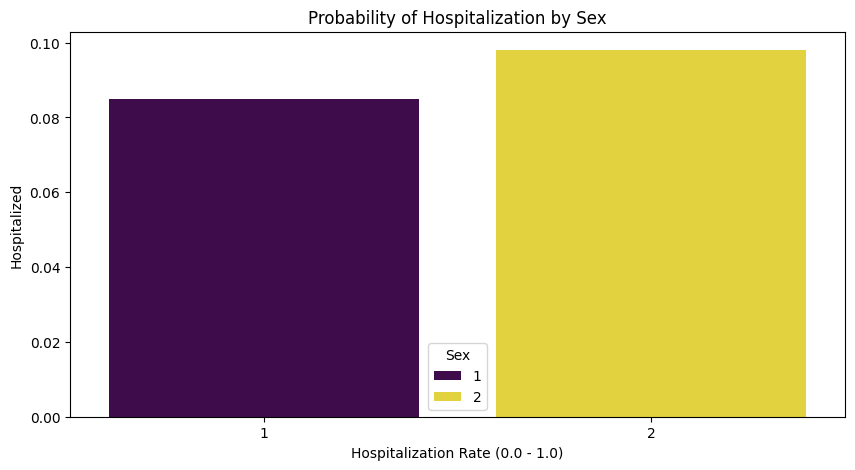

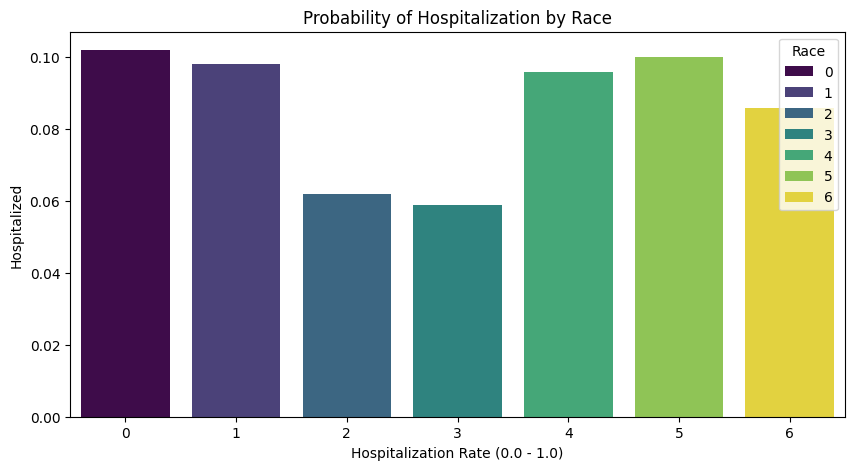

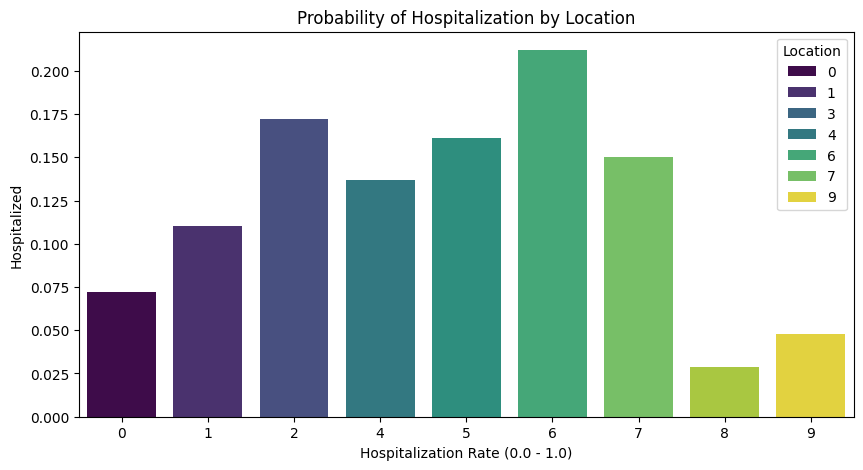

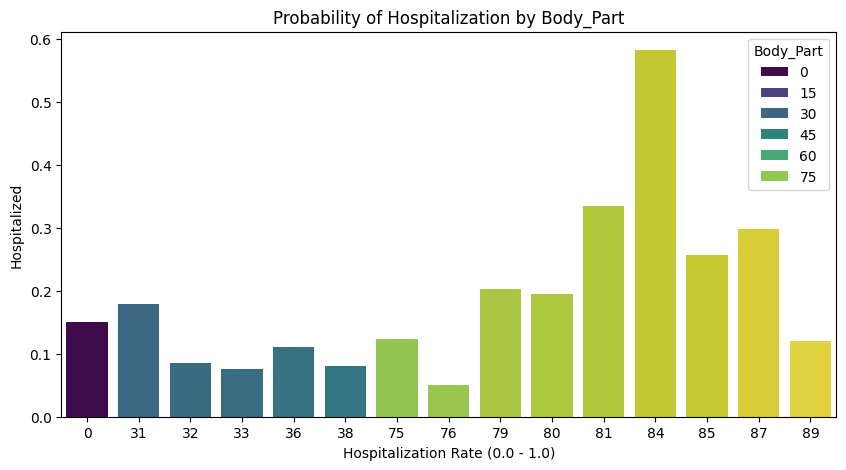

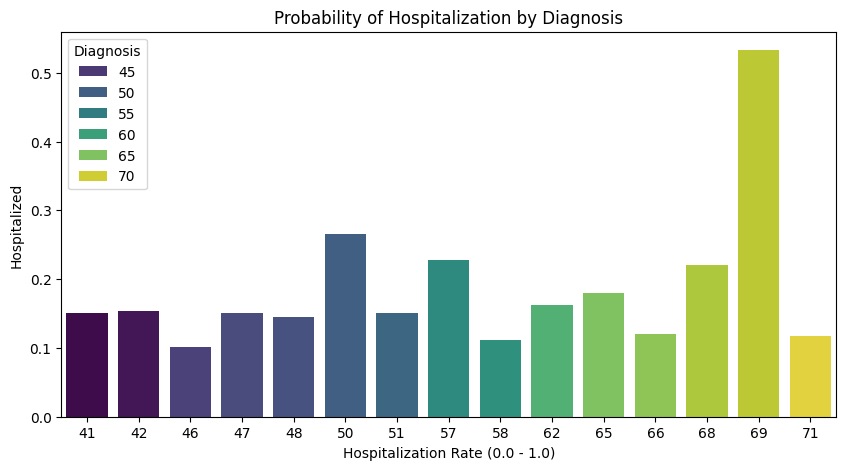

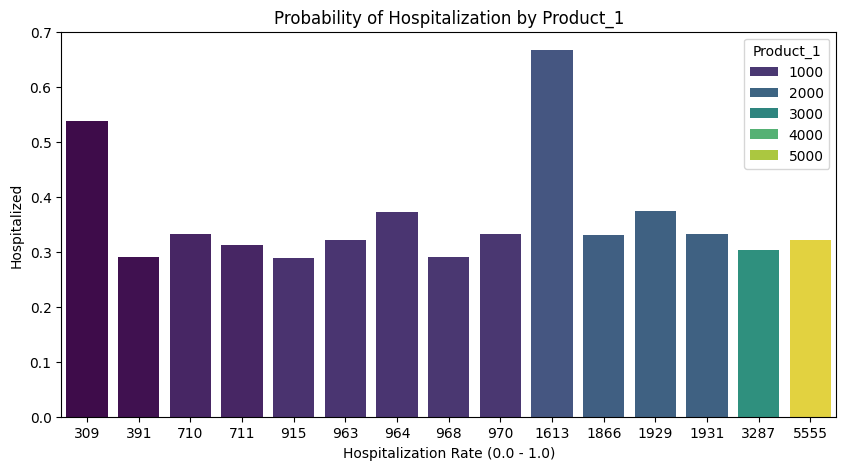

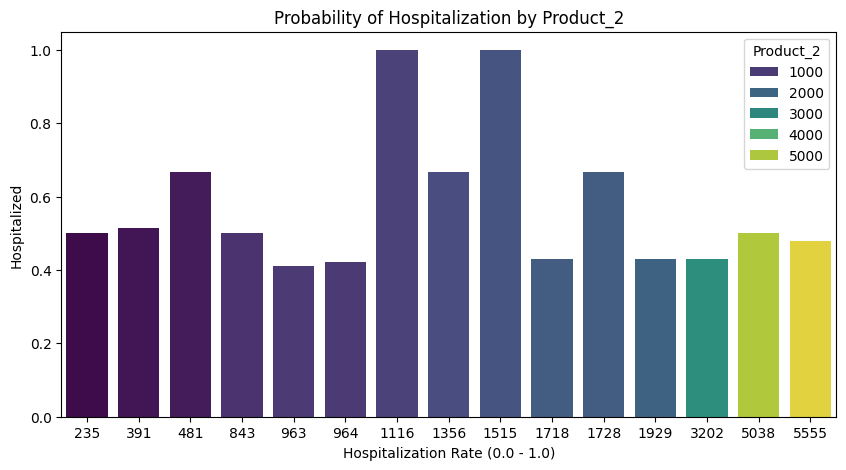

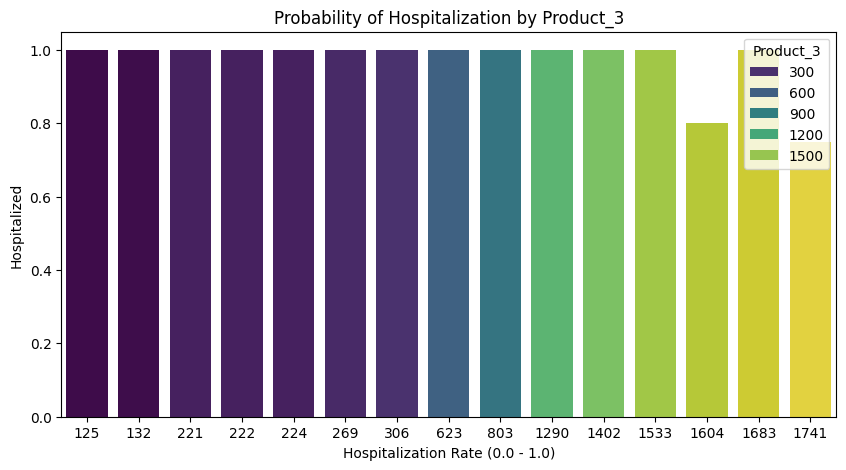

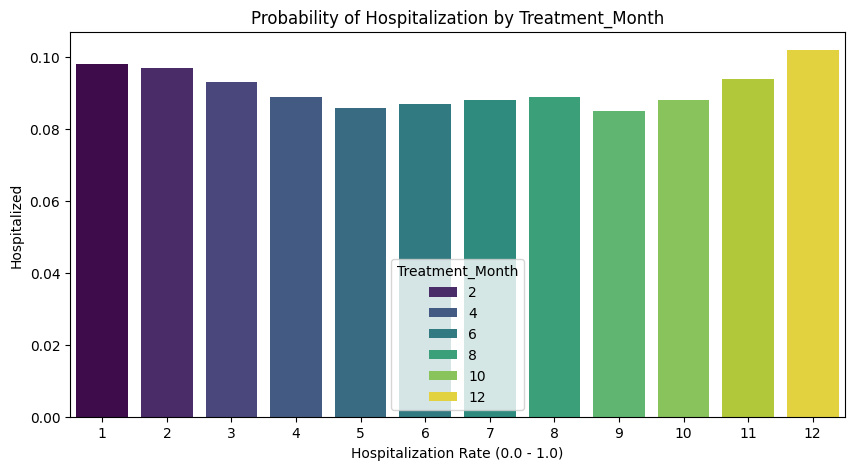

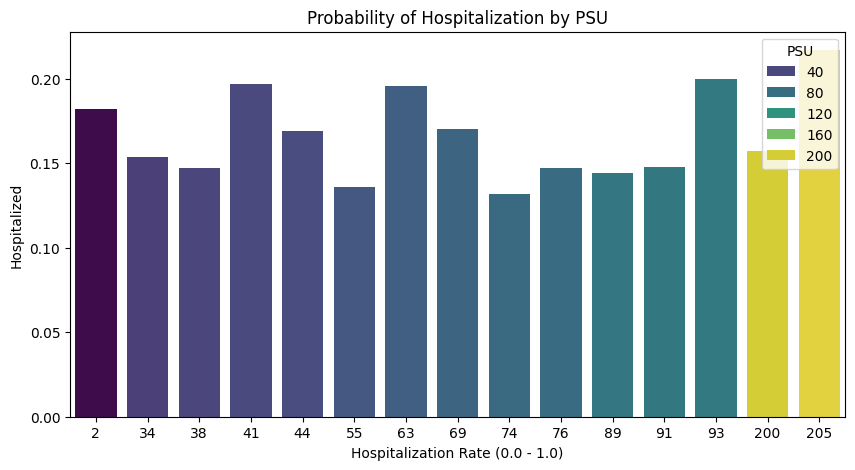

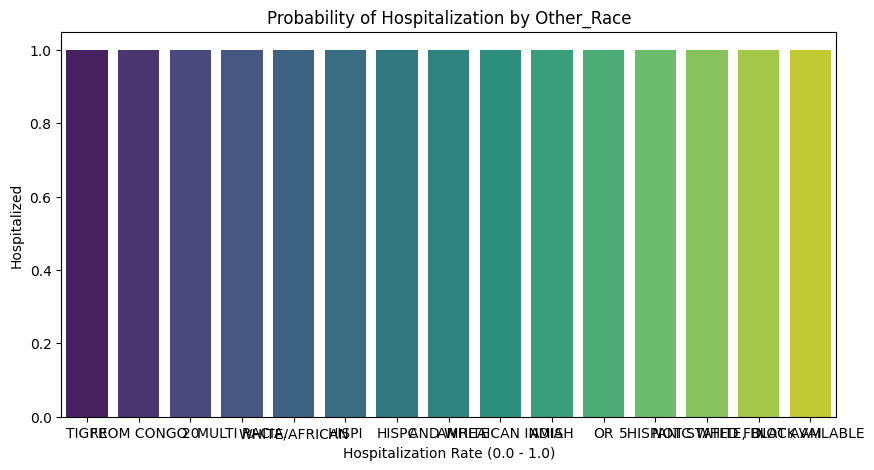

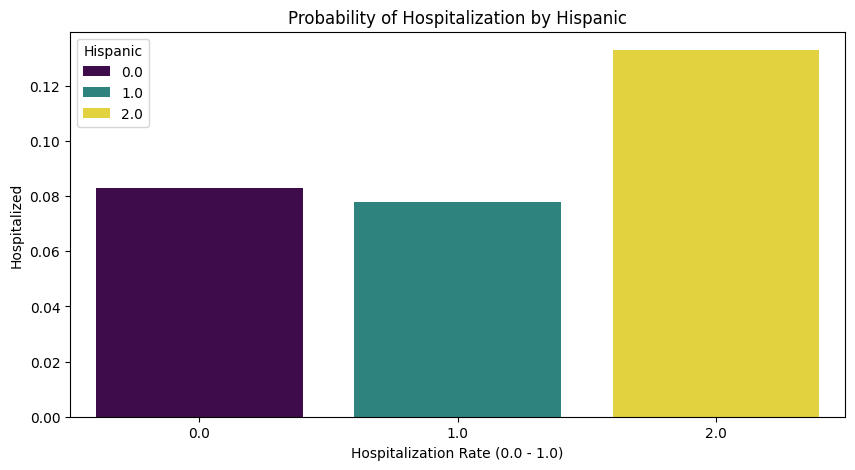

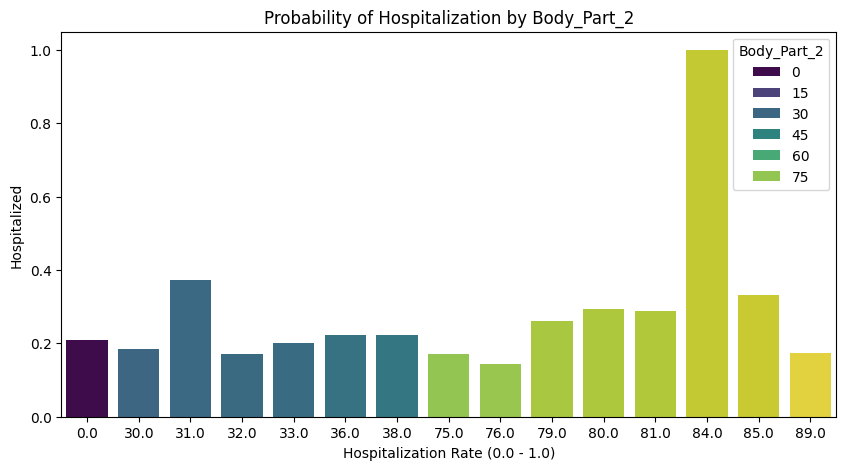

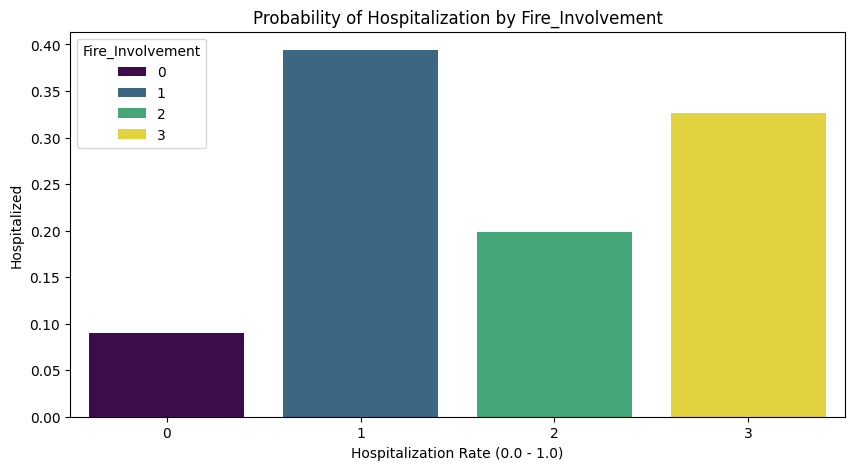

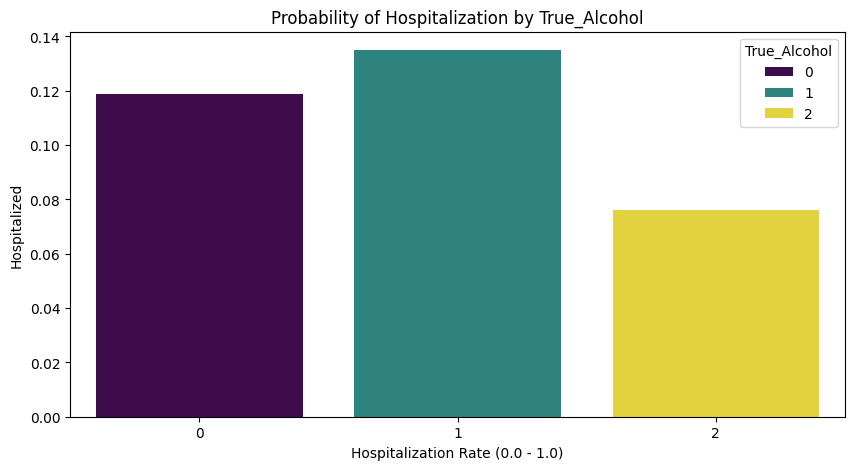

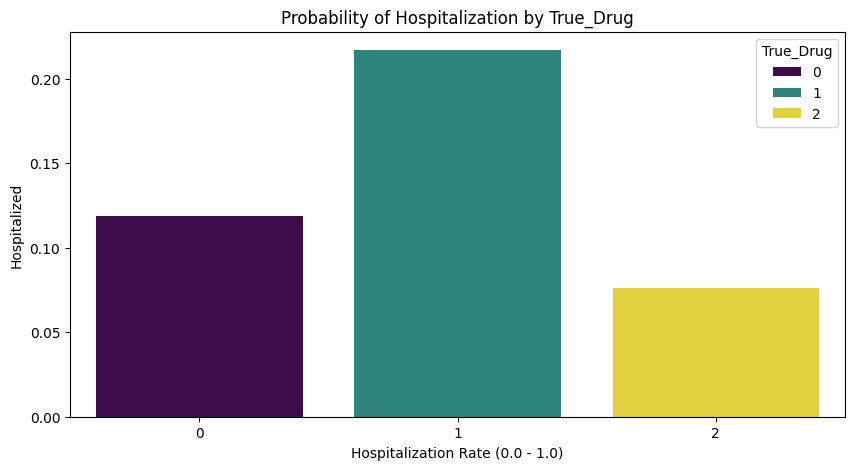

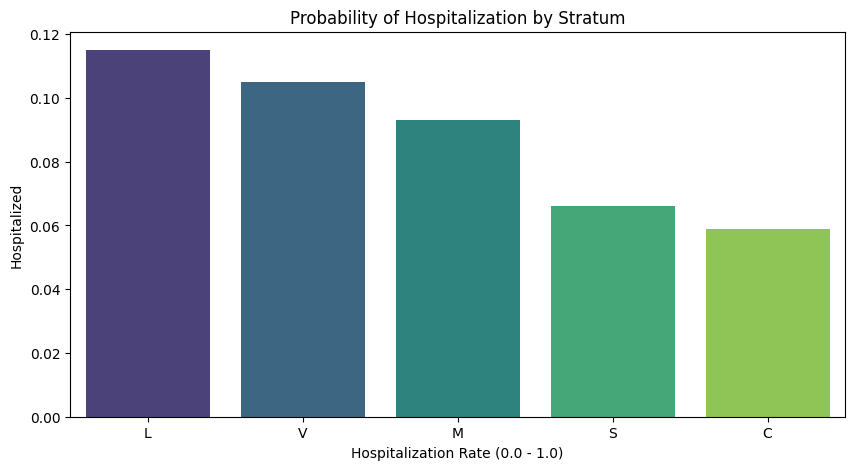

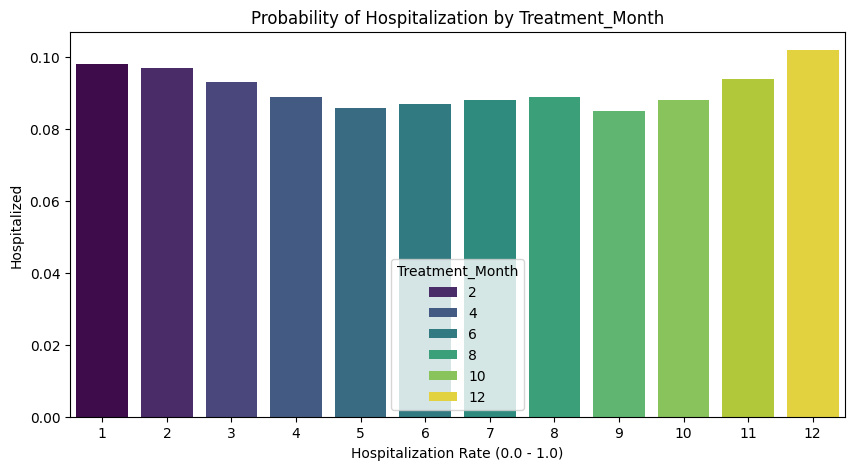

In [29]:
# Define categorical variables to analyze
categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Product_2','Product_3','Treatment_Month','PSU','Other_Race','Hispanic','Body_Part_2','Fire_Involvement','True_Alcohol','True_Drug','Stratum','Treatment_Month']

# Loop through and plot the "Risk"
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Calculate the mean of 'Target_Hospitalized' (which equals the % hospitalized)
    risk_df = data.groupby(col)['Hospitalized'].mean().round(3).reset_index().sort_values('Hospitalized', ascending=False)
    
    # Plot top 15 categories for readability
    sns.barplot(y='Hospitalized', x=col, data=risk_df.head(15), dodge=False, palette='viridis',hue=col)
    
    plt.title(f'Probability of Hospitalization by {col}')
    ##plt.xticks(rotation=90)
    plt.xlabel('Hospitalization Rate (0.0 - 1.0)')
    plt.show()

### 3.2 Run Chi-Square test to understand which categorical variables are significant

In [30]:
categorical_cols

['Sex',
 'Race',
 'Location',
 'Body_Part',
 'Diagnosis',
 'Product_1',
 'Product_2',
 'Product_3',
 'Treatment_Month',
 'PSU',
 'Other_Race',
 'Hispanic',
 'Body_Part_2',
 'Fire_Involvement',
 'True_Alcohol',
 'True_Drug',
 'Stratum',
 'Treatment_Month']

In [31]:
# Define categorical variables to analyze
#categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Other_Race','Hispanic','Fire_Involvement','True_Alcohol','True_Drug','Stratum','Treatment_Month']

# Loop through and plot the "Risk"
for col in categorical_cols:
    # Example: Check if Sex predicts Hospitalization
    contingency_table = pd.crosstab(data[col], data['Hospitalized'])
    #print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        print(f'{col} is a significant predictor.')
    else:
        print(f'{col} is likely noise.')

Sex is a significant predictor.
Race is a significant predictor.
Location is a significant predictor.
Body_Part is a significant predictor.
Diagnosis is a significant predictor.
Product_1 is a significant predictor.
Product_2 is a significant predictor.
Product_3 is a significant predictor.
Treatment_Month is a significant predictor.
PSU is a significant predictor.
Other_Race is a significant predictor.
Hispanic is a significant predictor.
Body_Part_2 is a significant predictor.
Fire_Involvement is a significant predictor.
True_Alcohol is a significant predictor.
True_Drug is a significant predictor.
Stratum is a significant predictor.
Treatment_Month is a significant predictor.


Per the chi-square test, all categorical variables a significant - this could be due to the volume of dataset - Large sample size effect. We need to further use the cramers 

In [32]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Your list of "Significant" variables
predictors = categorical_cols

# Calculate and Rank
results = []
for col in predictors:
    score = cramers_v(data[col], data['Hospitalized'])
    results.append({'Feature': col, 'Cramers_V Score': score})

# Show the leaderboard
rank_df = pd.DataFrame(results).sort_values(by='Cramers_V Score', ascending=False)
rank_df

,Feature,Cramers_V Score
4,Diagnosis,0.28
3,Body_Part,0.26
5,Product_1,0.23
9,PSU,0.15
2,Location,0.11
12,Body_Part_2,0.11
15,True_Drug,0.09
6,Product_2,0.08
14,True_Alcohol,0.08
16,Stratum,0.07


#### Categorical Features that are significant

In [33]:
rank_df[rank_df['Cramers_V Score'] > 0.1]

,Feature,Cramers_V Score
4,Diagnosis,0.28
3,Body_Part,0.26
5,Product_1,0.23
9,PSU,0.15
2,Location,0.11
12,Body_Part_2,0.11


Store these variables in the predictor variable

In [34]:
predictors_cat = rank_df[rank_df['Cramers_V Score'] > 0.1].Feature.tolist()

We note that PSU has a high Cramers V score. But PSU represents the Primary Sampling unit (hospital id) and using that for ML could cause data leakage. We need to ignore this feature.

In [35]:
predictors_cat.pop(predictors_cat.index('PSU'))
predictors_cat

['Diagnosis', 'Body_Part', 'Product_1', 'Location', 'Body_Part_2']

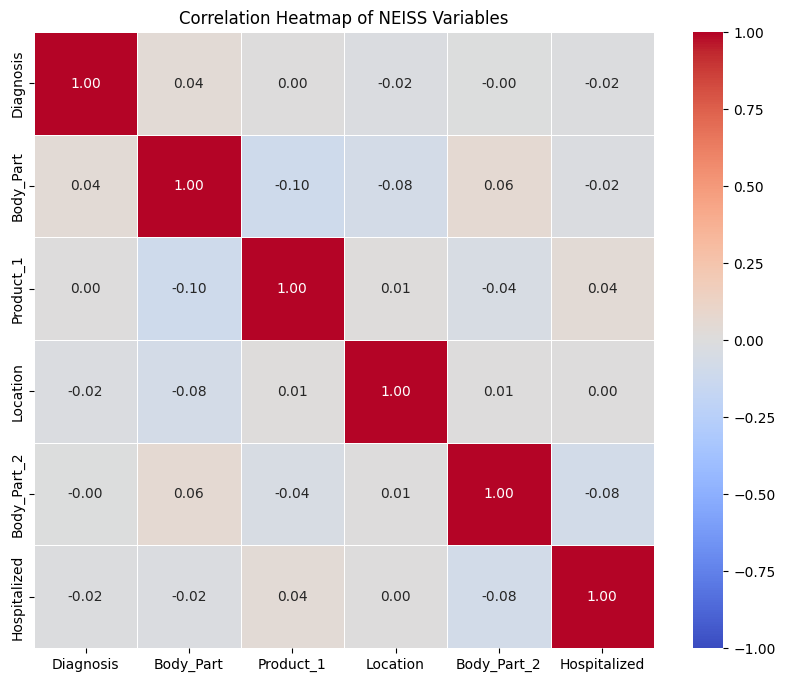

In [36]:
# 1. Prepare the Data
# Ensure categorical columns are numeric (codes)
cols_to_plot = predictors_cat + ['Hospitalized'] 
# 2. Calculate Correlation
# method='spearman' is best for categorical codes
corr_matrix = data[cols_to_plot].corr(method='spearman')

# 3. Create the Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,     # Show the numbers
    fmt=".2f",      # 2 decimal places
    cmap='coolwarm',# Red = Positive, Blue = Negative
    vmin=-1, vmax=1,# Lock scale between -1 and 1
    linewidths=0.5  # Add white lines between squares
)

plt.title('Correlation Heatmap of NEISS Variables')
plt.show()

#### 3.1 Understand the relationship between Numerical Features and the Target Variable

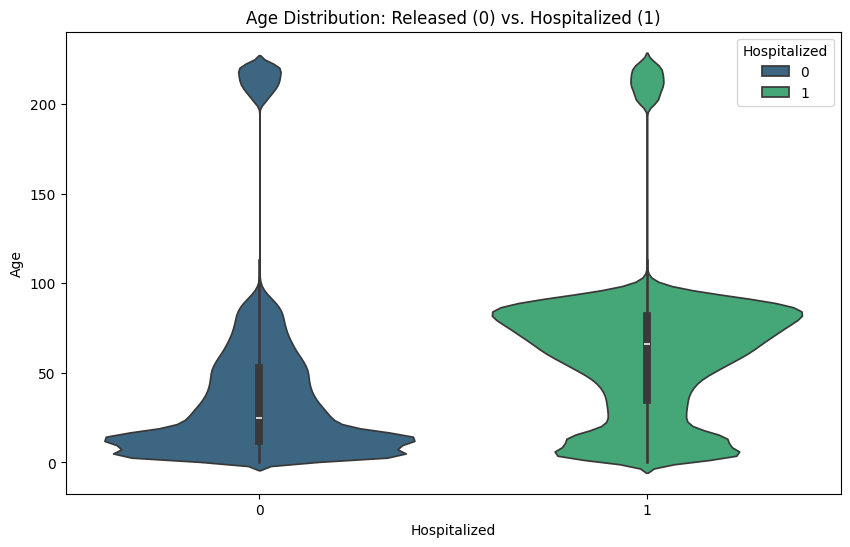

In [37]:
plt.figure(figsize=(10, 6))

# A Violin plot shows the shape of the data better than a box plot here
sns.violinplot(x='Hospitalized', y='Age', data=data, hue='Hospitalized', palette='viridis')

plt.title('Age Distribution: Released (0) vs. Hospitalized (1)')
plt.show()

In [38]:
predictors_num = ['Age']
print(f'Numeric Predictors: {predictors_num}')
print(f'Categorical Predictors: {predictors_cat}')

Numeric Predictors: ['Age']
Categorical Predictors: ['Diagnosis', 'Body_Part', 'Product_1', 'Location', 'Body_Part_2']


### 4. Perfrom Encoding for Categorical Fields 

In [39]:
target = ['Hospitalized']
data_cleaned = data[predictors_num + predictors_cat + target]

In [40]:
data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 7 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Age           int64  
 1   Diagnosis     int64  
 2   Body_Part     int64  
 3   Product_1     int64  
 4   Location      int64  
 5   Body_Part_2   float64
 6   Hospitalized  int64  
dtypes: float64(1), int64(6)
memory usage: 390.7 MB


In [41]:
data_cleaned['Diagnosis'] = data_cleaned['Diagnosis'].astype('category')
data_cleaned['Body_Part'] = data_cleaned['Body_Part'].astype('category')
data_cleaned['Product_1'] = data_cleaned['Product_1'].astype('category')
data_cleaned['Location'] = data_cleaned['Location'].astype('category')
data_cleaned['Body_Part_2'] = data_cleaned['Body_Part_2'].astype('category')
data_cleaned['Hospitalized'] = data_cleaned['Hospitalized'].astype('category')
data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 7 columns):
 #   Column        Dtype   
---  ------        -----   
 0   Age           int64   
 1   Diagnosis     category
 2   Body_Part     category
 3   Product_1     category
 4   Location      category
 5   Body_Part_2   category
 6   Hospitalized  category
dtypes: category(6), int64(1)
memory usage: 104.7 MB


In [42]:
data_cleaned.nunique()

Age             136
Diagnosis        30
Body_Part        26
Product_1       837
Location          9
Body_Part_2      26
Hospitalized      2
dtype: int64

We can use one-hot encoding to encode the below categorical varaibles:<br>
1. Diagnosis <br>
2. Body part <br>
3. Location <br>
4. Body Part_2 <br>

However, there are around 837 unique products in the Product_1 feature, using one-hot encoding to encode these many features could create more than 800 columns and could slow down the ML algorithms. We need a clever way to handle the Product_1 feature.

#### Perform One-Hot Encoding for the fields Diagnosis, Body Part, Location, Body Part_2

In [43]:
data_products = data.Product_1.value_counts().sort_values(ascending=False).reset_index()
data_products.columns = ['Product_1', 'Count']
data_products.head(20)

,Product_1,Count
0,1842,593336
1,1807,536216
2,4076,355670
3,1205,271340
4,5040,259578
5,1211,228234
6,4074,171260
7,1893,157719
8,1884,155758
9,464,153927


### 5. Save the data to the interim folder for future use

In [44]:
#data.to_csv('../data/processed/neiss_processed_data.csv', index=False)
data.to_parquet('../data/processed/neiss_processed_data.parquet')
data.to_parquet('../data/processed/neiss_cleaned_data.parquet')